# 使用OSMnx绘制等时线地图

Author: [Geoff Boeing](https://geoffboeing.com/)

步行15分钟可以走多远？

  - [Documentation](https://osmnx.readthedocs.io/)
  - [Journal article and citation info](https://doi.org/10.1111/gean.70009)
  - [Code repository](https://github.com/gboeing/osmnx)
  - [Examples gallery](https://github.com/gboeing/osmnx-examples)

In [1]:
#!uv pip install --system --quiet osmnx[all]
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
from shapely.geometry import LineString, Point, Polygon

ox.__version__

'2.0.6'

In [2]:
# 配置地点、网络类型、行程时间和出行速度
place = {"city": "Berkeley", "state": "California"}
network_type = "walk"
trip_times = [5, 10, 15, 20, 25]  # 单位：分钟
travel_speed = 4.5  # 步行速度，单位：公里/小时

## 下载并准备街道网络数据

In [3]:
# 下载街道网络数据
G = ox.graph.graph_from_place(place, network_type=network_type)

In [4]:
# 找到中心节点并将图形投影到UTM坐标系
gdf_nodes = ox.convert.graph_to_gdfs(G, edges=False)
x, y = gdf_nodes["geometry"].union_all().centroid.xy
center_node = ox.distance.nearest_nodes(G, x[0], y[0])
G = ox.projection.project_graph(G)

In [6]:
# 为每条边添加通过所需时间(分钟)的属性
meters_per_minute = travel_speed * 1000 / 60  # 将公里/小时转换为米/分钟
for _, _, _, data in G.edges(data=True, keys=True):
    data["time"] = data["length"] / meters_per_minute

## 绘制在指定时间内步行可到达的节点

从起点出发，5、10、15、20和25分钟内可以步行多远？我们将使用NetworkX根据行程时间和出行速度，为每个时间范围生成G的子图。

In [11]:
# 为每个等时线获取一种颜色
iso_colors = ox.plot.get_colors(n=len(trip_times), cmap="plasma", start=0)
iso_colors

['#0d0887', '#7e03a8', '#cc4778', '#f89540', '#f0f921']

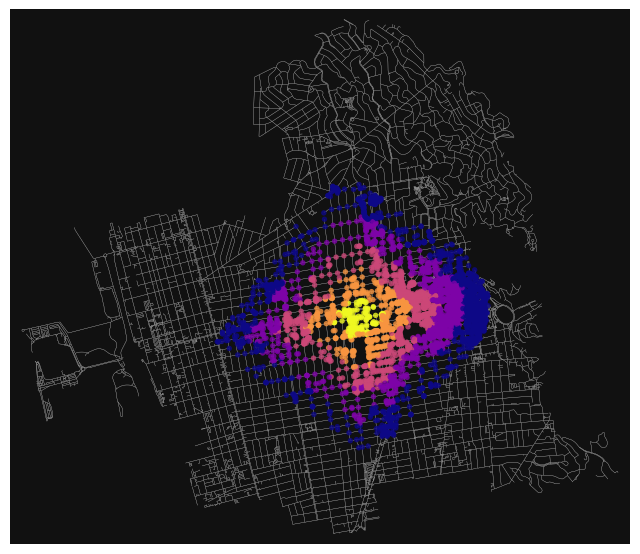

In [12]:
# 根据等时线为节点着色并绘制街道网络
node_colors = {}
for trip_time, color in zip(sorted(trip_times, reverse=True), iso_colors):
    subgraph = nx.ego_graph(G, center_node, radius=trip_time, distance="time")
    for node in subgraph.nodes():
        node_colors[node] = color
nc = [node_colors.get(node, "none") for node in G.nodes()]
ns = [15 if node in node_colors else 0 for node in G.nodes()]
fig, ax = ox.plot.plot_graph(
    G,
    node_color=nc,
    node_size=ns,
    node_alpha=0.8,
    edge_linewidth=0.2,
    edge_color="#999999",
)

## 将时间距离绘制为等时线

从起点出发，5、10、15、20和25分钟内可以步行多远？我们将使用凸包(convex hull)来表示，虽然不够精确。凹包(concave hull)会更好，但shapely库目前不提供这个功能。

In [13]:
# 创建等时线多边形
isochrone_polys = []
for trip_time in sorted(trip_times, reverse=True):
    subgraph = nx.ego_graph(G, center_node, radius=trip_time, distance="time")
    node_points = [Point((data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]
    bounding_poly = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(bounding_poly)
gdf = gpd.GeoDataFrame(geometry=isochrone_polys)
gdf

,geometry
0,"POLYGON ((564058.027 4190094.722, 562767.896 4..."
1,"POLYGON ((564074.13 4190405.42, 563473.496 419..."
2,"POLYGON ((564037.643 4190780.541, 563887.057 4..."
3,"POLYGON ((563995.308 4191103.932, 563895.31 41..."
4,"POLYGON ((563958.833 4191482.827, 563744.19 41..."


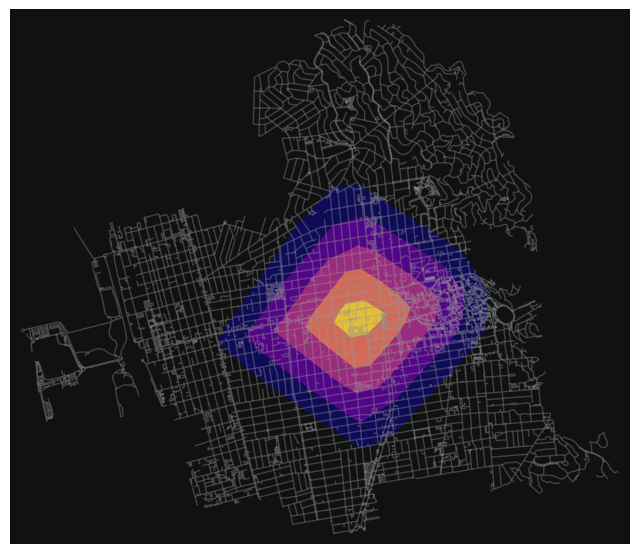

In [14]:
# 绘制街道网络并添加彩色多边形等时线
fig, ax = ox.plot.plot_graph(
    G,
    show=False,
    close=False,
    edge_color="#999999",
    edge_alpha=0.2,
    node_size=0,
)
gdf.plot(ax=ax, color=iso_colors, ec="none", alpha=0.6, zorder=-1)
plt.show()

## 或者，将等时线绘制为缓冲区，这样可以得到比凸包更精确的等时线表示

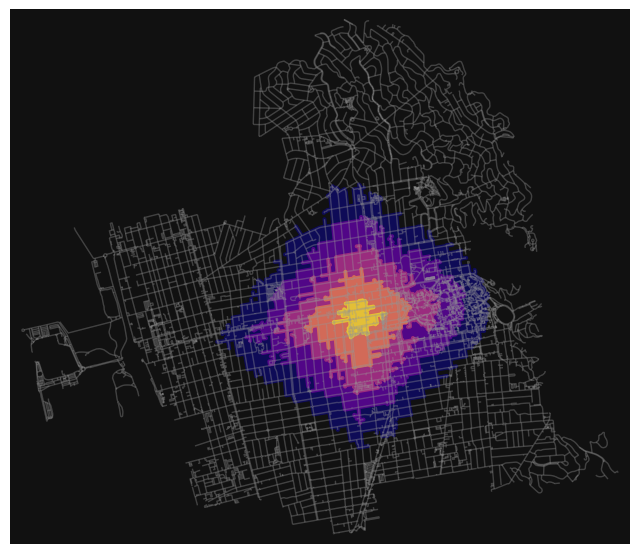

In [15]:
def make_iso_polys(G, edge_buff=25, node_buff=50, infill=False):
    """创建等时线多边形"""
    isochrone_polys = []
    for trip_time in sorted(trip_times, reverse=True):
        subgraph = nx.ego_graph(G, center_node, radius=trip_time, distance="time")

        node_points = [Point((data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]
        nodes_gdf = gpd.GeoDataFrame({"id": list(subgraph.nodes)}, geometry=node_points)
        nodes_gdf = nodes_gdf.set_index("id")

        edge_lines = []
        for n_fr, n_to in subgraph.edges():
            f = nodes_gdf.loc[n_fr].geometry
            t = nodes_gdf.loc[n_to].geometry
            edge_lookup = G.get_edge_data(n_fr, n_to)[0].get("geometry", LineString([f, t]))
            edge_lines.append(edge_lookup)

        n = nodes_gdf.buffer(node_buff).geometry
        e = gpd.GeoSeries(edge_lines).buffer(edge_buff).geometry
        all_gs = list(n) + list(e)
        new_iso = gpd.GeoSeries(all_gs).union_all()

        # 尝试填充被包围的区域，使形状显示为实心且内部没有空白
        if infill:
            new_iso = Polygon(new_iso.exterior) # type: ignore
        isochrone_polys.append(new_iso)
    return isochrone_polys


# 创建等时线多边形
isochrone_polys = make_iso_polys(G, edge_buff=25, node_buff=0, infill=True)
gdf = gpd.GeoDataFrame(geometry=isochrone_polys)

# 绘制街道网络并添加彩色多边形等时线
fig, ax = ox.plot.plot_graph(
    G,
    show=False,
    close=False,
    edge_color="#999999",
    edge_alpha=0.2,
    node_size=0,
)
gdf.plot(ax=ax, color=iso_colors, ec="none", alpha=0.6, zorder=-1)
plt.show()